### Opening a FITS file


A FITS (Flexible Image Transport System) file is commonly used to store scientific data. 
The file-type allow to store the data in slightly different ways, and it can therefore be good to manually check the specific files of interest to make sure the data is interpreted meaningfully. 
The FITS file contains of one or several HDU's (Header Data Unit), which each is parted in two distinct sections: Header and Data. 
The Header section contains meta-data infomration relevant to interpret what is stored in the Data section. 
The Data section can contain data of any dimensions, for instance an image, a spectrogram or a cube.



Reading the FITS files can be done through various tools, profiled to handle different tasks aiding to the analysis of the data. This guide shows briefly how to inspect a solar radio FITS file manually. 
Please also refer to the documentation on e.g., astropy FITS handling:
https://docs.astropy.org/en/stable/io/fits/index.html

#### Example how to open a FITS file in python, and check what HDU's the file contains:



In [63]:
from astropy.io import fits

## We use an example solar radio FITS file that can be found here: 
## https://cdn.obs-nancay.fr/repository/nda/mefisto/soleil/2023/03/

fits_filename='orn_nda_newroutine_sun_edr_202303070802_202303070936_v1.1.fits'  ## Change your path to the file here
hdul = fits.open(fits_filename)
hdul.info()

Filename: orn_nda_newroutine_sun_edr_202303070802_202303070936_v1.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      75   ()      
  1  SETUP         1 BinTableHDU     12   1R x 1C   [1598E]   
  2  SCIENCE       1 BinTableHDU     15   11538R x 2C   [1D, 3196E]   
  3  ACQUISITION    1 BinTableHDU     36   94R x 9C   [1D, 1E, 1E, 1E, 1E, 1I, 1I, 1I, 1I]   


#### The content of the HDU headers can be examined like this:

In [64]:
for i, hdu in enumerate(hdul):
    print("\n"*2+'='*16)
    print(f'hdu {i}: {hdu.name}')
    print("="*16)
    print(hdu.header.tostring(sep='\n'))



hdu 0: PRIMARY
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
---     = '/ DATA DESCRIPTION '                                                 
TITLE   = 'ORN NDA newroutine SUN EDR Dataset' / Title of the dataset           
ORIGIN  = 'ORN     '           / Observatoire Radioastronomique de Nancay       
CONTACT = 'contact_nda at obs-nancay.fr' / Contact email adress                 
PI_NAME = 'L.Lamy  '           / Principal Investigator                         
PUBLISHE= 'PADC    '           / Publisher of the dataset                       
OBJECT  = 'Sun     '           / Target observed                                
DATE    = '2023-03-07'         / Date of file creation                          
FILENAME= '

#### It should be noted that different instruments and dataproducts use different variations on the keywords.
#### Specific meta-data parameters can be extracted and checked manually, for example:


In [73]:
# Observational time range:
date_beg = hdul[0].header["DATE-BEG"]
date_end = hdul[0].header["DATE-END"]
time_beg = hdul[0].header["TSTART"]
time_end = hdul[0].header["TSTOP"]
print('Observation time range:', date_beg,'T',time_beg, '--', date_end,'T',time_end)


Observation time range: 2023-03-07 T 08:02:27.259 -- 2023-03-07 T 09:36:59.579


In [83]:
# Frequency range and resolution
freq_min = hdul[0].header["FREQMIN"]
freq_max = hdul[0].header["FREQMAX"]
freq_unit = hdul[1].header["TUNIT1"]
df = hdul[0].header["DF"]
print('Frequency range:', freq_min, '--', freq_max, freq_unit)
print('Frequency steps:', df, freq_unit)


Frequency range: 10.01 -- 87.99 MHz
Frequency steps: 0.048828125 MHz



#### The content of the HDU data can be accessed e.g.:

In [88]:
# Frequency axis
freq = hdul[1].data["frq"][0]

print("Number of frequency channels:", len(freq))
print("First frequency:", freq[0], "MHz")
print("Last frequency:", freq[-1], "MHz")

Number of frequency channels: 1598
First frequency: 10.009766 MHz
Last frequency: 87.98828 MHz


In [89]:
# Temporal axis
time = hdul[2].data["jd"] # Julian date

# Dynamic spectrum
data = hdul[2].data["data"] #Shape: (time, frequency channels, polarization channels)

In [100]:
print("Data shape:", data.shape)
print("Total size:", data.size)
print("min:", np.nanmin(data))
print("max:", np.nanmax(data))
print("mean:", np.nanmean(data))

Data shape: (11538, 1598, 2)
Total size: 36875448
min: 1.453042e+06
max: 4.832883e+13
mean: 3.4769992e+09


#### Example of plotting part of the data for inspection:

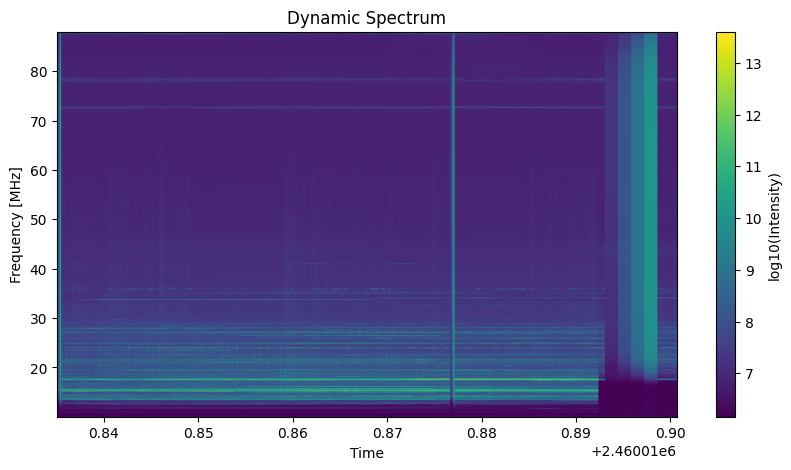

In [105]:
spec = np.log10(data[:, :, 0].T + 1e-3)

plt.figure(figsize=(10, 5))
plt.imshow(spec, aspect="auto", origin="lower", extent=[time[0], time[-1], freq[0], freq[-1]])
plt.colorbar(label="log10(Intensity)")
plt.xlabel("Time")
plt.ylabel("Frequency [MHz]")
plt.title("Dynamic Spectrum")
plt.show()